In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, r2_score

In [2]:
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

import joblib

rf = joblib.load("../models/random_forest.pkl")
xgb = joblib.load("../models/xgboost.pkl")

rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

In [4]:
rmse_rf = mean_squared_error(y_test, rf_pred)
rmse_xgb = mean_squared_error(y_test, xgb_pred)

r2_rf = r2_score(y_test, rf_pred)
r2_xgb = r2_score(y_test, xgb_pred)

print("Random Forest RMSE:", rmse_rf)
print("XGBoost RMSE:", rmse_xgb)

print("\nRandom Forest R2:", r2_rf)
print("XGBoost R2:", r2_xgb)

Random Forest RMSE: 11.574685356917227
XGBoost RMSE: 6.001760959625244

Random Forest R2: 0.9821558975944322
XGBoost R2: 0.9907473921775818


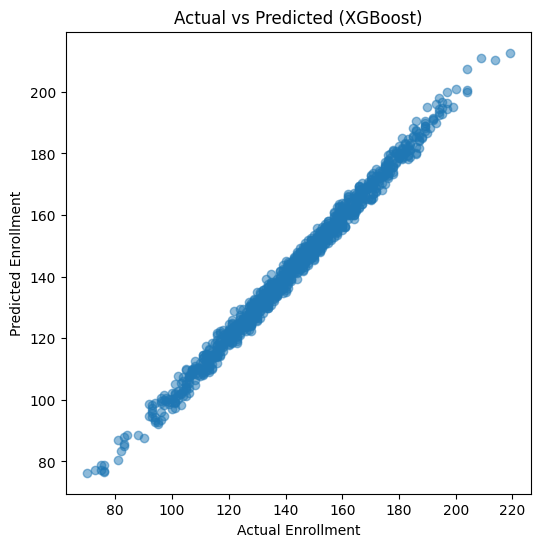

In [5]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, xgb_pred, alpha=0.5)
plt.xlabel("Actual Enrollment")
plt.ylabel("Predicted Enrollment")
plt.title("Actual vs Predicted (XGBoost)")
plt.show()

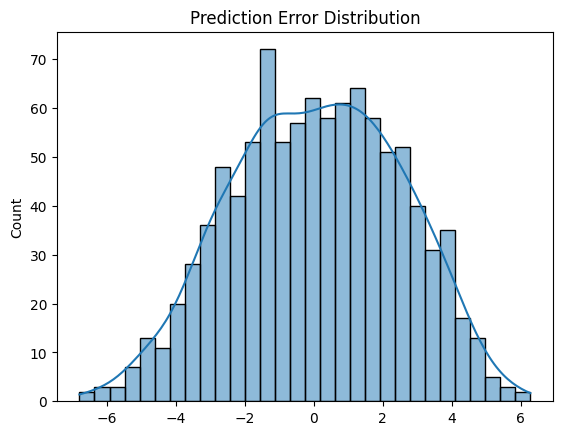

In [6]:
errors = y_test - xgb_pred

sns.histplot(errors, bins=30, kde=True)
plt.title("Prediction Error Distribution")
plt.show()

In [7]:
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": xgb.feature_importances_
}).sort_values(by="importance", ascending=False)

importance_df.head(10)

,feature,importance
9,9,0.510724
7,7,0.198678
1,1,0.102945
5,5,0.085577
3,3,0.050246
6,6,0.030280
2,2,0.011563
4,4,0.008904
8,8,0.000392
10,10,0.000371


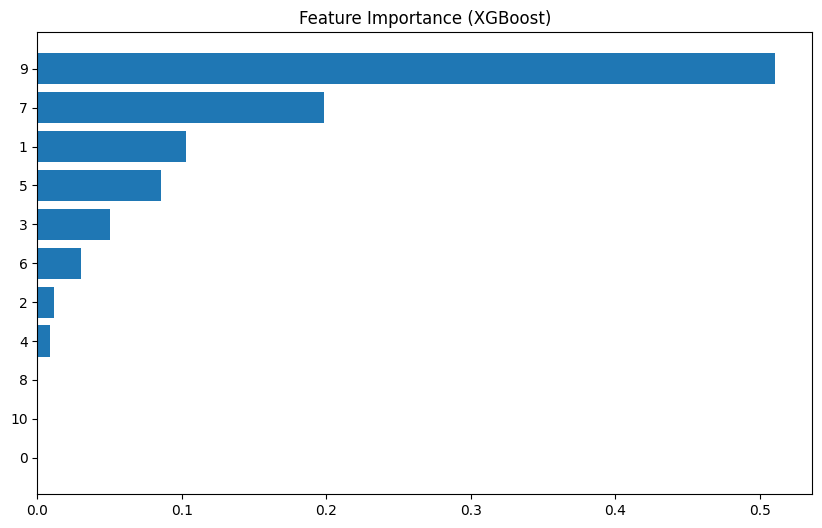

In [8]:
plt.figure(figsize=(10,6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (XGBoost)")
plt.show()

### Key Insights:

1. Courses with higher waitlists show strong demand and should be expanded.
2. Capacity constraints directly limit enrollment growth.
3. Higher feedback and faculty ratings improve enrollment significantly.
4. Demand ratio is a strong indicator for course scaling decisions.

### Recommendations:

- Increase capacity for high-demand courses
- Improve course quality to boost retention
- Optimize scheduling to reduce waitlists

In [9]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "RMSE": [rmse_rf, rmse_xgb],
    "R2 Score": [r2_rf, r2_xgb]
})

comparison

,Model,RMSE,R2 Score
0,Random Forest,11.574685,0.982156
1,XGBoost,6.001761,0.990747


### Final Conclusion:

XGBoost outperformed Random Forest in predicting enrollment due to its ability to capture complex feature interactions.

The model can be used for:
- forecasting course demand
- optimizing resource allocation
- improving academic planning decisions